In [ ]:
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch.nn as nn
from transformers import Trainer
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

folder_path = "/content/drive/MyDrive/DS310/Dataset/merged_data/"

Mounted at /content/drive


In [ ]:
train_df = pd.read_csv(folder_path + "train.csv")
val_df = pd.read_csv(folder_path + "val.csv")
test_df = pd.read_csv(folder_path + "test.csv")

In [ ]:
X_train = train_df['full_story']
y_train = train_df['category'].astype('category').cat.codes

X_val = val_df['full_story']
y_val = val_df['category'].astype('category').cat.codes

X_test = test_df['full_story']
y_test = test_df['category'].astype('category').cat.codes

In [ ]:
# Label encoding
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['category'])
val_df['label']   = le.transform(val_df['category'])
test_df['label']  = le.transform(test_df['category'])

num_labels = len(le.classes_)
print("Số class:", num_labels)

Số class: 12


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Tesla T4


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_labels),
    y=train_df['label'].values
)

class_weights = torch.tensor(class_weights, dtype=torch.float).cuda()
print(class_weights)

tensor([0.9984, 0.9984, 0.9996, 0.9972, 0.9984, 1.0033, 1.0033, 1.0008, 0.9984,
        1.0033, 1.0008, 0.9984], device='cuda:0')


In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset

In [ ]:
model_name = "bert-base-uncased"  # hoặc "roberta-base", "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
train_ds = Dataset.from_dict({
    "text": train_df['full_story'].tolist(),
    "label": train_df['label'].tolist()
})
val_ds = Dataset.from_dict({
    "text": val_df['full_story'].tolist(),
    "label": val_df['label'].tolist()
})
test_ds = Dataset.from_dict({
    "text": test_df['full_story'].tolist(),
    "label": test_df['label'].tolist()
})

In [ ]:
# Tokenize
def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=512)

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/9848 [00:00<?, ? examples/s]

Map:   0%|          | 0/1231 [00:00<?, ? examples/s]

Map:   0%|          | 0/1232 [00:00<?, ? examples/s]

In [ ]:
columns = ['input_ids', 'attention_mask', 'label']
train_ds.set_format(type='torch', columns=columns)
val_ds.set_format(type='torch', columns=columns)
test_ds.set_format(type='torch', columns=columns)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
).cuda()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        if torch.cuda.is_available():
            labels = labels.cuda()
            for k in inputs:
                if isinstance(inputs[k], torch.Tensor):
                    inputs[k] = inputs[k].cuda()

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    do_train=True,
    do_eval=True,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=1,
    num_train_epochs=4,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=50,
    save_steps=500,
)

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer
)

/tmp/ipython-input-540045305.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23521488 (21522798-uit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
50,2.533600
100,2.296200
150,2.100700
200,1.869100
250,1.738700
300,1.583200
350,1.560300
400,1.814100
450,1.460300
500,1.549500


TrainOutput(global_step=9848, training_loss=1.155970611386334, metrics={'train_runtime': 4281.6761, 'train_samples_per_second': 9.2, 'train_steps_per_second': 2.3, 'total_flos': 1.036540127674368e+16, 'train_loss': 1.155970611386334, 'epoch': 4.0})

In [ ]:
checkpoint_path = "./results/checkpoint-8500"
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_path)

trainer = Trainer(model=model, tokenizer=tokenizer)

preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = test_df['label'].values

# Đánh giá
print("Test Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=le.classes_))

/tmp/ipython-input-2915087796.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer)


Test Accuracy: 0.5081168831168831
                    precision    recall  f1-score   support

 business_industry       0.78      0.88      0.83       103
     computer_math       0.42      0.49      0.45       102
     earth_climate       0.35      0.38      0.36       103
education_learning       0.69      0.64      0.66       103
     fossils_ruins       0.67      0.72      0.69       103
   health_medicine       0.45      0.35      0.39       103
       living_well       0.35      0.28      0.31       102
     matter_energy       0.41      0.29      0.34       103
        mind_brain       0.39      0.54      0.45       102
    plants_animals       0.35      0.34      0.35       102
   science_society       0.33      0.28      0.30       103
        space_time       0.83      0.89      0.86       103

          accuracy                           0.51      1232
         macro avg       0.50      0.51      0.50      1232
      weighted avg       0.50      0.51      0.50      1232



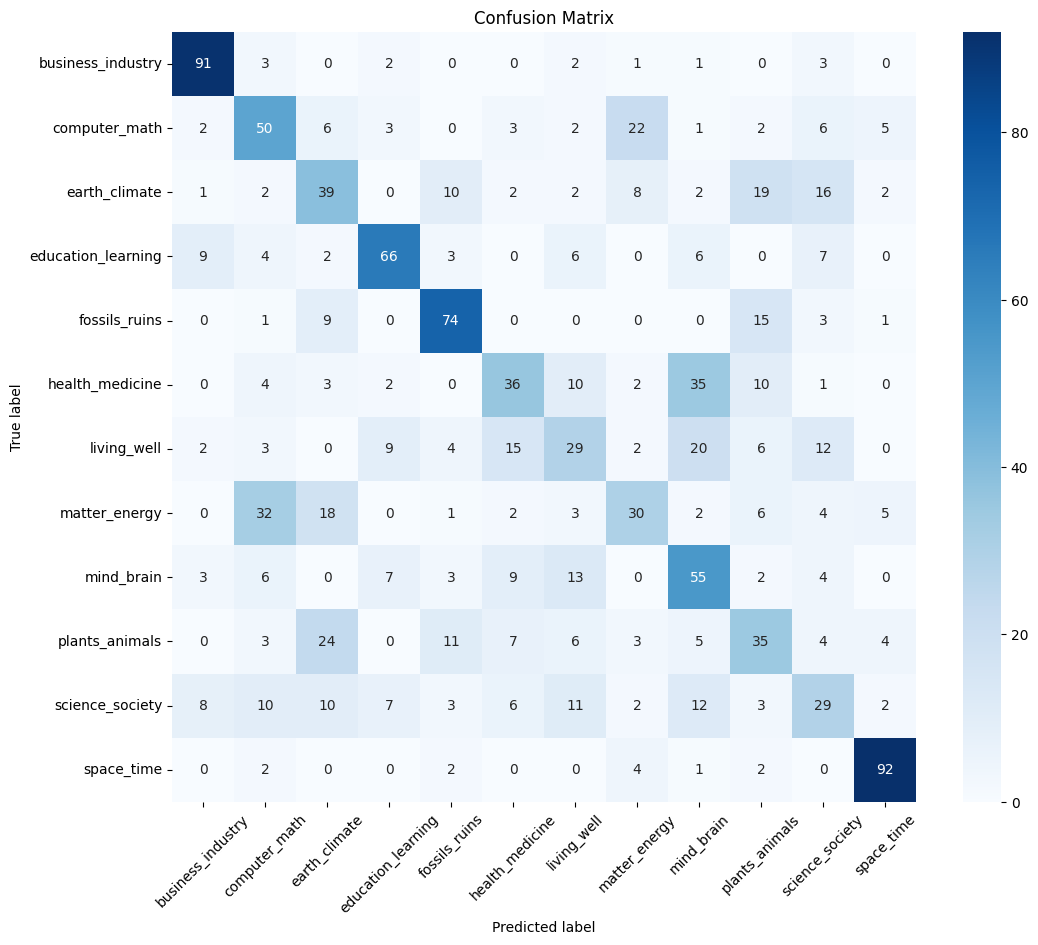

In [ ]:
class_names = [
    "business_industry", "computer_math", "earth_climate", "education_learning",
    "fossils_ruins", "health_medicine", "living_well", "matter_energy",
    "mind_brain", "plants_animals", "science_society", "space_time"
]

# Tạo confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Chuyển sang DataFrame để dễ vẽ
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Vẽ heatmap
plt.figure(figsize=(12,10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

Các lớp dự đoán tốt:

- space_time (92/103 đúng, recall ~0.89) → dễ phân biệt.

- business_industry (91/103 đúng, recall ~0.88) → khá tốt.

- fossils_ruins (74/103 đúng, recall ~0.72) → khá ổn.

Các lớp dự đoán kém:

- living_well (29/102 đúng, recall ~0.28) → nhiều nhầm lẫn với mind_brain, matter_energy.

- science_society (29/103 đúng, recall ~0.28) → nhầm với computer_math, earth_climate.

- plants_animals (35/102 đúng, recall ~0.34) → nhầm với earth_climate và fossils_ruins.